<a href="https://colab.research.google.com/github/ojumoolatimi/decision-tree-vs-random-forest/blob/main/cervical_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score




warnings.filterwarnings('ignore')


In [68]:
def wrangle(filepath):
    df = pd.read_csv(filepath)

    #STDs- Time since first/last diagnosis — 92% missing, unusable
    df.drop(columns=['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis'], inplace=True)

    #drop columns with data leakages
    df.drop(columns=['Hinselmann', 'Schiller', 'Citology'], inplace=True)

    #drop diagnostic labels, keeping them would cause data leakage
    df.drop(columns=['Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx'], inplace=True)

    #convert ? to nan
    df = df.replace('?', np.nan)

    #change the data type from object to int
    df['Number of sexual partners'] = df['Number of sexual partners'].astype(float)
    df['First sexual intercourse'] = df['First sexual intercourse'].astype(float)
    df['Num of pregnancies'] = df['Num of pregnancies'].astype(float)
    df['Smokes'] = df['Smokes'].astype(float)
    df['Smokes (years)'] = df['Smokes (years)'].astype(float)
    df['Smokes (packs/year)'] = df['Smokes (packs/year)'].astype(float)
    df['Hormonal Contraceptives'] = df['Hormonal Contraceptives'].astype(float)
    df['Hormonal Contraceptives (years)'] = df['Hormonal Contraceptives (years)'].astype(float)
    df['IUD'] = df['IUD'].astype(float)
    df['IUD (years)'] = df['IUD (years)'].astype(float)
    df['STDs'] = df['STDs'].astype(float)
    df['STDs (number)'] = df['STDs (number)'].astype(float)
    df['STDs:condylomatosis'] = df['STDs:condylomatosis'].astype(float)
    df['STDs:cervical condylomatosis'] = df['STDs:cervical condylomatosis'].astype(float)
    df['STDs:vaginal condylomatosis'] = df['STDs:vaginal condylomatosis'].astype(float)
    df['STDs:vulvo-perineal condylomatosis'] = df['STDs:vulvo-perineal condylomatosis'].astype(float)
    df['STDs:syphilis'] = df['STDs:syphilis'].astype(float)
    df['STDs:pelvic inflammatory disease'] = df['STDs:pelvic inflammatory disease'].astype(float)
    df['STDs:genital herpes'] = df['STDs:genital herpes'].astype(float)
    df['STDs:molluscum contagiosum'] = df['STDs:molluscum contagiosum'].astype(float)
    df['STDs:AIDS'] = df['STDs:AIDS'].astype(float)
    df['STDs:HIV'] = df['STDs:HIV'].astype(float)
    df['STDs:Hepatitis B'] = df['STDs:Hepatitis B'].astype(float)
    df['STDs:HPV'] = df['STDs:HPV'].astype(float)
    df['STDs: Number of diagnosis'] = df['STDs: Number of diagnosis'].astype(float)

    #drop multicolineary column
    df.drop(columns = ['Smokes (packs/year)', 'IUD (years)'], inplace = True)





    return df

In [69]:
df = wrangle('/content/drive/MyDrive/dataset/risk_factors_cervical_cancer.csv')
df.head(10)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,STDs,...,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,Biopsy
0,18,4.0,15.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,15,1.0,14.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,34,1.0,NaN,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,52,5.0,16.0,4.0,1.0,37.000000,1.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,46,3.0,21.0,4.0,0.0,0.000000,1.0,15.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,42,3.0,23.0,2.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,51,3.0,17.0,6.0,1.0,34.000000,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
7,26,1.0,26.0,3.0,0.0,0.000000,1.0,2.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
8,45,1.0,20.0,5.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,44,3.0,15.0,NaN,1.0,1.266973,0.0,0.0,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Hormonal Contraceptives             750 non-null    float64
 7   Hormonal Contraceptives (years)     750 non-null    float64
 8   IUD                                 741 non-null    float64
 9   STDs                                753 non-null    float64
 10  STDs (number)                       753 non-null    float64
 11  STDs:condylomatosis                 753 non-n

In [58]:
df.isnull().sum()/len(df) * 100

,0
Age,0.000000
Number of sexual partners,3.030303
First sexual intercourse,0.815851
Num of pregnancies,6.526807
Smokes,1.515152
Smokes (years),1.515152
Hormonal Contraceptives,12.587413
Hormonal Contraceptives (years),12.587413
IUD,13.636364
IUD (years),13.636364


In [59]:
df.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),...,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,Biopsy
count,858.000000,832.000000,851.000000,802.000000,845.000000,845.000000,750.000000,750.000000,741.000000,741.000000,...,753.000000,753.000000,753.000000,753.000000,753.0,753.000000,753.000000,753.000000,858.000000,858.000000
mean,26.820513,2.527644,16.995300,2.275561,0.145562,1.219721,0.641333,2.256419,0.112011,0.514804,...,0.023904,0.001328,0.001328,0.001328,0.0,0.023904,0.001328,0.002656,0.087413,0.064103
std,8.497948,1.667760,2.803355,1.447414,0.352876,4.089017,0.479929,3.764254,0.315593,1.943089,...,0.152853,0.036442,0.036442,0.036442,0.0,0.152853,0.036442,0.051503,0.302545,0.245078
min,13.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.000000,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.000000,2.000000,17.000000,2.000000,0.000000,0.000000,1.000000,0.500000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32.000000,3.000000,18.000000,3.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
max,84.000000,28.000000,32.000000,11.000000,1.000000,37.000000,1.000000,30.000000,1.000000,19.000000,...,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,3.000000,1.000000


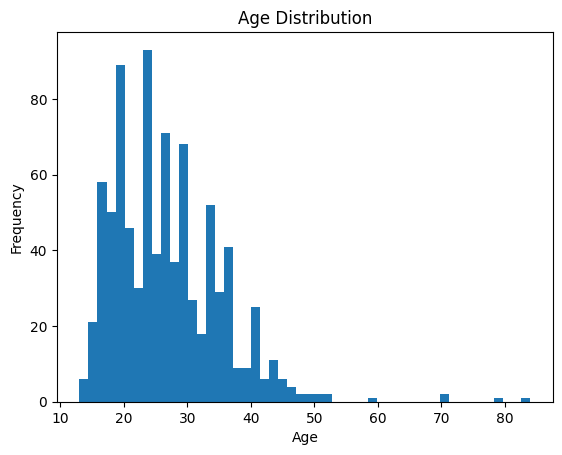

In [60]:
#distrribution age
df['Age'].plot(kind='hist', bins=50)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The distributions overlap but the positive group skews right.

In [48]:
corr = df[['Smokes',  'Smokes (years)', 'Smokes (packs/year)']].corr()
corr

,Smokes,Smokes (years),Smokes (packs/year)
Smokes,1.000000,0.723128,0.493361
Smokes (years),0.723128,1.000000,0.724116
Smokes (packs/year),0.493361,0.724116,1.000000


<Axes: >

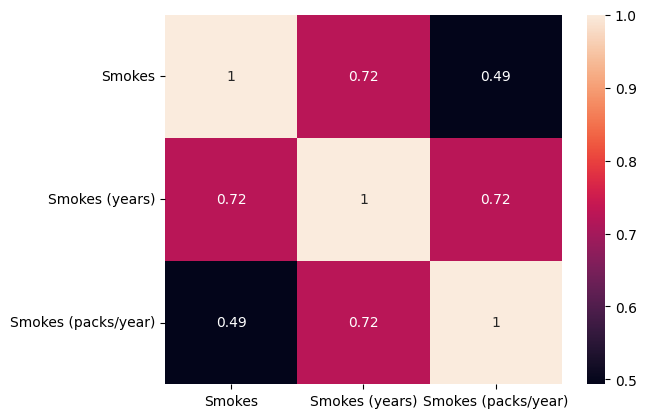

In [49]:
sns.heatmap(corr, annot = True)

In [52]:
#checking the differenc
pd.DataFrame({'smokes year' : df['Smokes (years)'],
              'smokes year/packs' : df['Smokes (packs/year)']}).head(20)

,smokes year,smokes year/packs
0,0.000000,0.0
1,0.000000,0.0
2,0.000000,0.0
3,37.000000,37.0
4,0.000000,0.0
5,0.000000,0.0
6,34.000000,3.4
7,0.000000,0.0
8,0.000000,0.0
9,1.266973,2.8


In [66]:
corr_IUD = df[['IUD', 'IUD (years)']].corr()
corr_IUD

,IUD,IUD (years)
IUD,1.000000,0.746478
IUD (years),0.746478,1.000000


<Axes: >

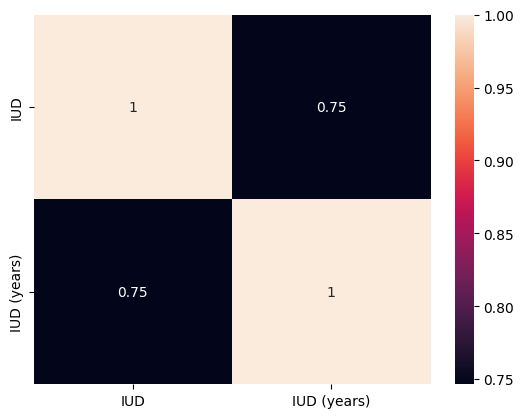

In [67]:
sns.heatmap(corr_IUD, annot = True)

Exploring the target

In [71]:
df['Biopsy'].value_counts(normalize = True)

,proportion
Biopsy,
0,0.935897
1,0.064103


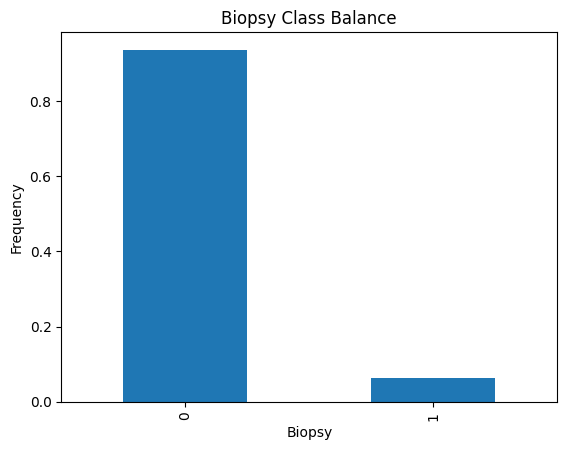

In [74]:
df['Biopsy'].value_counts(normalize = True).plot(kind = 'bar')
plt.title('Biopsy Class Balance')
plt.xlabel('Biopsy')
plt.ylabel('Frequency')
plt.show()

Split

In [77]:
target = 'Biopsy'
X = df.drop(columns = target)
y = df[target]


print('X shape: ', X.shape)
print('y shape: ', y.shape)

X shape:  (858, 24)
y shape:  (858,)


In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print('X_train shape: ', X_train.shape)
print('y_train shape: ', y_train.shape)
print('X_test shape: ', X_test.shape)
print('y_test shape: ', y_test.shape)

X_train shape:  (686, 24)
y_train shape:  (686,)
X_test shape:  (172, 24)
y_test shape:  (172,)


Resample

In [86]:
over_sampler = RandomOverSampler(random_state = 42)
X_train_resampled, y_train_resampled = over_sampler.fit_resample(X_train, y_train)
print('X_train_over shape:', X_train_resampled.shape)
print('y_train_over shape:', y_train_resampled.shape)

X_train_over shape: (1284, 24)
y_train_over shape: (1284,)


Build Model

Baseline model

In [87]:
baseline_acc = y_train.value_counts(normalize = True).max()
print('Baseline Accuracy:', baseline_acc)


Baseline Accuracy: 0.9358600583090378
